<a href="https://colab.research.google.com/github/swastika241013006033-cmyk/AIML-Lab/blob/main/Problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


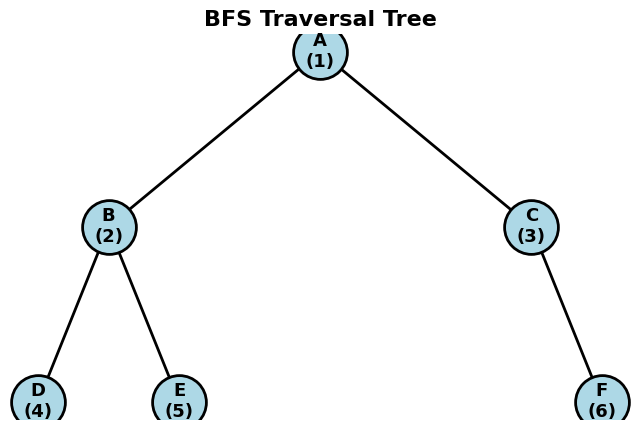

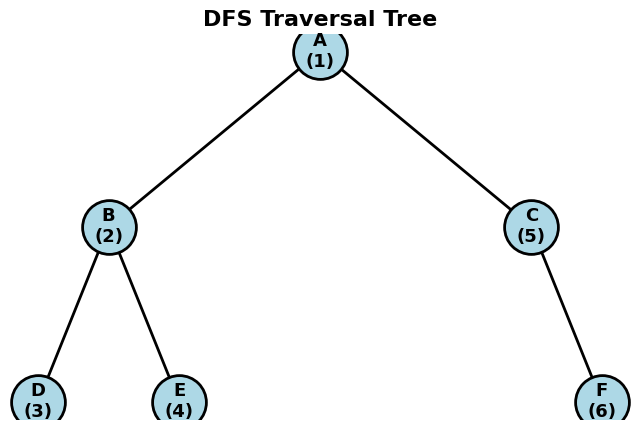

In [3]:
import matplotlib.pyplot as plt
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.add(node)
            order.append(node)

            for neighbour in graph[node]:
                if neighbour not in visited:
                    queue.append(neighbour)

    return order

def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()

    if order is None:
        order = []

    visited.add(start)
    order.append(start)

    for neighbour in graph[start]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, order)

    return order

bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))

def draw_tree(order, title):
    positions = {
        'A': (0, 3),
        'B': (-1.5, 2),
        'C': (1.5, 2),
        'D': (-2, 1),
        'E': (-1, 1),
        'F': (2, 1)
    }

    plt.figure(figsize=(8, 5))

    edges = [
        ('A', 'B'),
        ('A', 'C'),
        ('B', 'D'),
        ('B', 'E'),
        ('C', 'F')
    ]

    for parent, child in edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]
        plt.plot([x1, x2], [y1, y2], 'k-', linewidth=2)

    for node in positions:
        x, y = positions[node]
        visit_number = order.index(node) + 1

        plt.scatter(
            x, y,
            s=1500,
            color='lightblue',
            edgecolor='black',
            linewidth=2,
            zorder=2
        )

        plt.text(
            x, y,
            f"{node}\n({visit_number})",
            ha='center',
            va='center',
            fontsize=13,
            fontweight='bold'
        )

    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

draw_tree(bfs_order, "BFS Traversal Tree")
draw_tree(dfs_order, "DFS Traversal Tree")